In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import matplotlib.animation as animation
from IPython.display import HTML

# Longitudes aproximadas (metros) basadas en antropometría promedio
L_lumbar_shoulder = 0.55  # lumbar → hombro
L_shoulder_elbow = 0.30   # hombro → codo
L_elbow_hand = 0.25       # codo → mano

L = [L_lumbar_shoulder, L_shoulder_elbow, L_elbow_hand]

In [13]:
def FK(q):
    theta1, theta2, theta3 = q
    
    x1 = L[0] * np.cos(theta1)
    y1 = L[0] * np.sin(theta1)
    
    x2 = x1 + L[1] * np.cos(theta1 + theta2)
    y2 = y1 + L[1] * np.sin(theta1 + theta2)
    
    x3 = x2 + L[2] * np.cos(theta1 + theta2 + theta3)
    y3 = y2 + L[2] * np.sin(theta1 + theta2 + theta3)
    
    return np.array([x3, y3])

In [14]:
angle_bounds = [
    (np.deg2rad(-45), np.deg2rad(45)),   # lumbar
    (np.deg2rad(-90), np.deg2rad(120)),  # hombro
    (np.deg2rad(0), np.deg2rad(150))     # codo
]

In [15]:
def IK_error(q, target):
    pos = FK(q)
    return np.sum((pos - target)**2)

In [16]:
def IK(target, q_seed):
    
    res = minimize(
        IK_error,
        x0=q_seed,
        args=(target,),
        bounds=angle_bounds
    )
    
    return res.x

In [17]:
def lifting_trajectory(n_points=120):
    
    # posición inicial (suelo)
    x0, y0 = 0.4, 0.1
    
    # posición final (~1 m altura)
    xf, yf = 0.5, 1.0
    
    s = np.linspace(0,1,n_points)
    
    x = x0 + (xf-x0)*s
    y = y0 + (yf-y0)*s
    
    return x, y

In [18]:
def lifting_trajectory(n_points=120):

    s = np.linspace(0,1,n_points)

    # posición de caja en suelo
    x_pick = 0.45
    y_pick = 0.08

    # posición final (peldaño ~1m)
    x_place = 0.55
    y_place = 1.0

    # trayectoria curva tipo levantamiento humano
    x = x_pick + (x_place - x_pick)*s
    
    # curva suave para evitar levantar recto
    y = y_pick + (y_place - y_pick)*(3*s**2 - 2*s**3)

    return x, y

In [19]:
xList, yList = lifting_trajectory()

qList = []
q_seed = [0,0,0]

for i in range(len(xList)):
    
    target = np.array([xList[i],yList[i]])
    
    q = IK(target,q_seed)
    
    qList.append(q)
    
    q_seed = q

In [20]:
def joint_positions(q):
    
    theta1,theta2,theta3 = q
    
    A = np.array([0,0])
    
    B = A + np.array([
        L[0]*np.cos(theta1),
        L[0]*np.sin(theta1)
    ])
    
    C = B + np.array([
        L[1]*np.cos(theta1+theta2),
        L[1]*np.sin(theta1+theta2)
    ])
    
    D = C + np.array([
        L[2]*np.cos(theta1+theta2+theta3),
        L[2]*np.sin(theta1+theta2+theta3)
    ])
    
    return A,B,C,D

In [21]:
def plotMechanism(q,ax=None):
    
    A,B,C,D = joint_positions(q)
    
    if ax is None:
        ax = plt.figure().add_subplot(111)
    
    ax.plot([A[0],B[0]],[A[1],B[1]],'blue')
    ax.plot([B[0],C[0]],[B[1],C[1]],'red')
    ax.plot([C[0],D[0]],[C[1],D[1]],'magenta')
    
    ax.scatter(D[0],D[1],color='black')
    
    ax.set_aspect('equal')
    ax.set_xlim(-5,5.0)
    ax.set_ylim(-5,5)

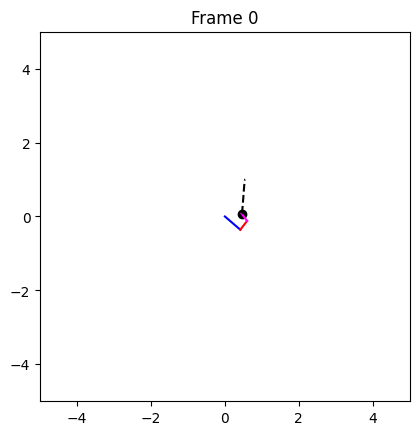

In [22]:
fig, ax = plt.subplots()

def update(i):
    
    ax.clear()
    
    plotMechanism(qList[i],ax)
    
    ax.plot(xList,yList,'k--')
    
    ax.set_title(f"Frame {i}")

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(qList),
    interval=60,
    repeat=False
)

HTML(anim.to_jshtml())